# Generating CDFs

Most distributions are discovered by being curious about the world. Someone watches a phenomenon unfold, asks what mechanism could generate it, and then recognizes the mathematical pattern. It's good to remember that math is discovered, not invented.

In each of the following parts, there is a description of a simulation. Each of these simulations generates one of the following distributions, along with its name in `scipy.stats`:

| Distribution | SciPy PDF/PMF                               | SciPy CDF                                   | Parameters                          |
| ------------ | ------------------------------------------- | ------------------------------------------- | ----------------------------------- |
| Beta         | `beta.pdf(x, a, b)`                         | `beta.cdf(x, a, b)`                         | $(a,b)$                             |
| Pareto       | `pareto.pdf(x, b, scale=xm)`                | `pareto.cdf(x, b, scale=xm)`                | shape $b$, minimum $x_m$ |
| Uniform      | `uniform.pdf(x, loc=a, scale=b-a)`          | `uniform.cdf(x, loc=a, scale=b-a)`          | lower $a$, upper $b$            |
| Lognormal    | `lognorm.pdf(x, s=sigma, scale=np.exp(mu))` | `lognorm.cdf(x, s=sigma, scale=np.exp(mu))` | $\log X\sim N(\mu,\sigma^2)$      |
| Normal       | `norm.pdf(x, loc=mu, scale=sigma)`          | `norm.cdf(x, loc=mu, scale=sigma)`          | $(\mu,\sigma)$                      |
| Exponential  | `expon.pdf(x, scale=1/lam)`                 | `expon.cdf(x, scale=1/lam)`                 |  $\lambda$                   |


For parts 1-8 below, program and run the described simulation, plot its distribution using the ECDF, and compare with the distributions above.

Which simulations generate which CDFs?

# **Pick four simulations to complete. You do not have to do all of them.**

# I chose to do Q2, Q4, Q6, and Q7

starting function we will use in the below questions

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(seed=100)


 

**Q2.** 

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

<Axes: ylabel='Proportion'>

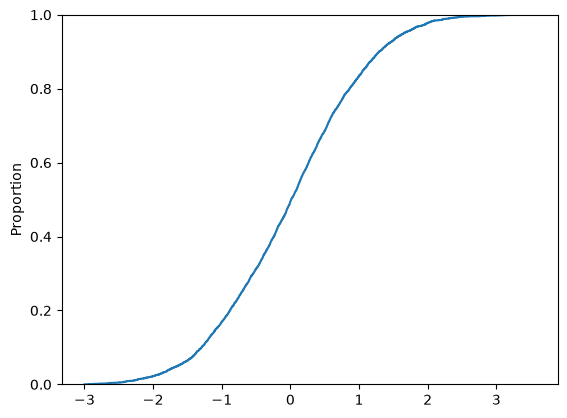

In [15]:
n, b = 32, 5_000

#draw all b samples, have a bxn matrix and one row per sample
X = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))

#mean of each sample, times sqrt(n)
Z = np.sqrt(n) * X.mean(axis=1)

sns.ecdfplot(Z)

The ECDF is S-shaped and symmetric around 0, going from about -3 to 3. Of the distributions in the table, only the Uniform and Normal ones take negative values, and a uniform cdf would be a stright line, so we choose to compare with the normal cdf using mu=0 and sigma=1.

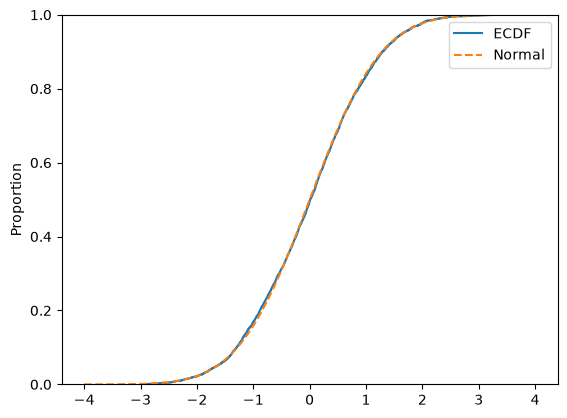

In [16]:
sns.ecdfplot(Z, label='ECDF')

x = np.linspace(-4, 4, 100)

plt.plot(x, stats.norm.cdf(x, loc=0, scale=1), '--', label='Normal')

plt.legend()

Looking above, the normal cdf lies right on top of the ecdf, thus the scaled sample mean has a normal distribution, and as n increases, ecdf gets closer and closer to the normal cdf above.

**Q4.** 

A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?
5. How do the results change as you adjust $r$?

<Axes: ylabel='Proportion'>

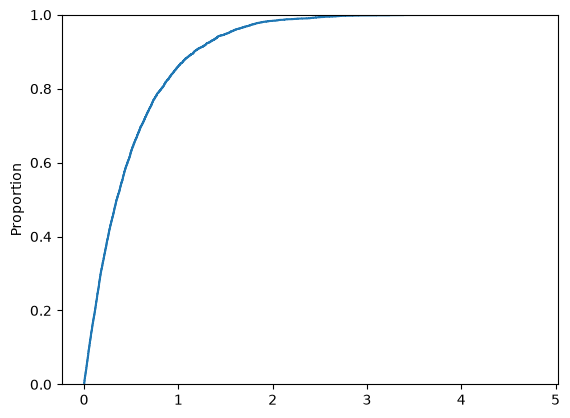

In [17]:
r, dt, n = 2.0, 1e-3, 5_000 #r not specified but we use 2


times=[]
for i in range(n):
    period = 1

    while rng.random() >= r * dt: #process didn't terminate
        period +=1
    times.append(period*dt)


times=np.array(times)


sns.ecdfplot(times)

Looking above, the times are all positive, and the ecdf rises steeply from 0 and then flattens out, with no S-shape. This seems to be the shape of an expoential cdf.

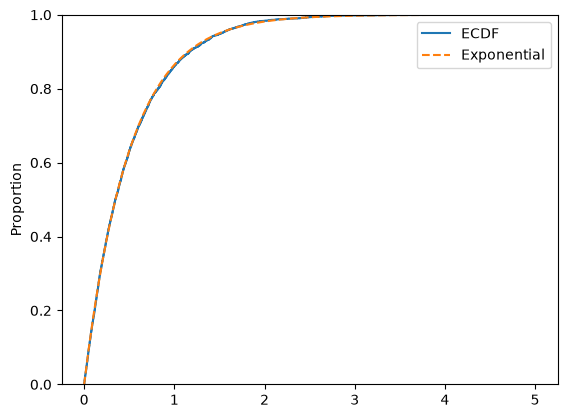

In [18]:
sns.ecdfplot(times, label='ECDF')

x=np.linspace(0, 5, 100)

plt.plot(x, stats.expon.cdf(x, scale=1/r), '--', label='Exponential')

plt.legend()

The exponential cdf with lambda=r lies right on top of the ecdf, thus as dt goes to zero this approaches the exponential distribution w/ rate r. Increasing r makes the process terminate sooner, thus the ecdf rises faster.

**Q6.**

Many things in the world grow through a long sequence of small proportional gains and losses: prices bounce around in response to information, tumors grow and shrink, populations expand and contract. When those tiny changes accumulate randomly over time, they produce recognizable patterns.

1. Start at a state of `1`.
2. Split a unit of time into $1/\Delta$ small time steps. Start with $\Delta = 1/100$, so $\{0, 1/100, 2/100, ... 99/100\}$.
3. Each period, the state is multiplied by $u = exp(\sqrt{\Delta})$ with probability $p=1/2$ or multiplied by $d = exp(-\sqrt{\Delta})$ with probability $1-p=1/2$.
4. Repeat steps 1-3 `B = 1_000` times and record the final position, and plot the ECDF of your sample.
5. What distribution does this approach as $\Delta$ gets close to zero?

<Axes: ylabel='Proportion'>

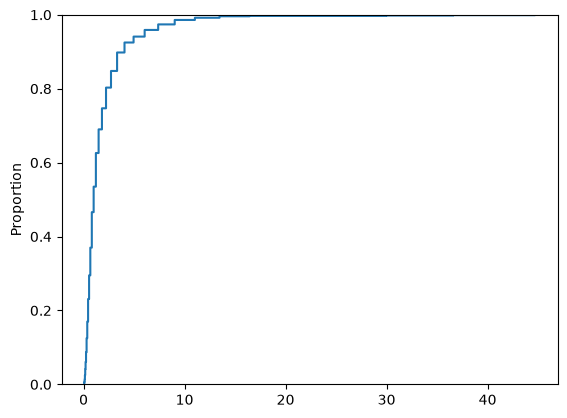

In [21]:
Delta = 1/100

B=1_000
u = np.exp(np.sqrt(Delta))
d=np.exp(-np.sqrt(Delta))

final=[]
for i in range(B):
    state=1
    for t in range(int(1/Delta)):
        if rng.random() < 0.5:
            state = state*u
        else:
            state = state*d
        
    final.append(state)

final=np.array(final)

sns.ecdfplot(final)

Looking above, the final positions are all positive, and about half are below 1 which is the starting point, and most are close to 1, and a few are far larger. The ecdf rises steeply and then has a long flat tail to the right. This seems to be the shape of a right-skewed positive variable like lognormal as shown in the table.

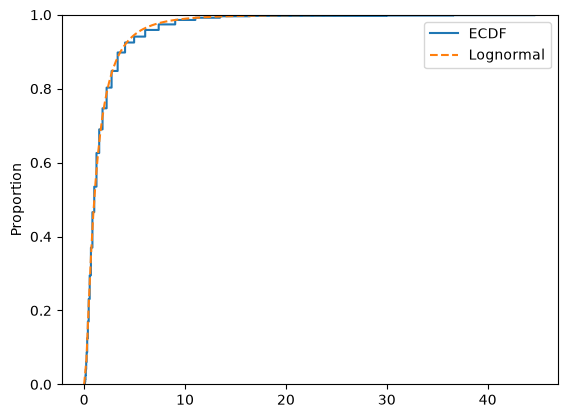

In [22]:
sns.ecdfplot(final, label='ECDF')

x = np.linspace(0, final.max(), 200)

plt.plot(x, stats.lognorm.cdf(x, s=1, scale=np.exp(0)), '--', label='Lognormal')
plt.legend()

The lognormal cdf with mu=0 and sigma=1 lies on top of the ecdf, thus as delta gets close to zero this approaches the lognormal distribution.

**Q7.**

A surprising regularity appears again and again in human populations: the second-largest city is often roughly half the size of the largest, the third-largest roughly one-third the size, and so on. This relationship is called Zipf's law, and it connects the rank of an observation to its size.

1. Suppose there are `K = 100_000` cities, ranked from largest to smallest. Create the ranks $r= \{ 1,..., K\}$.
2. Zipf's law says that the size of the city with rank $r$ is proportional to
$ 
x_r = \left(K/r \right)^s. 
$
Start with $s=1$.
3. Randomly sample `n=5_000` ranks, with each rank equally likely, and record the corresponding sizes.
4. Plot the ECDF of the simulated sizes.
5. What distribution does this generate as $K$ becomes large?
6. How does the distribution change as you adjust $s$?

(1.0, 50.0)

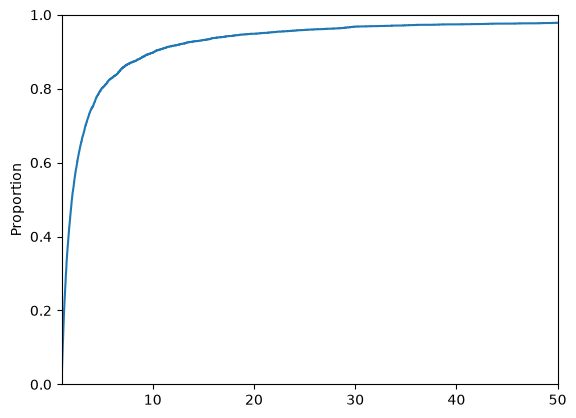

In [25]:
K, s, n = 100_000, 1, 5_000

r = np.arange(1, K+1) #ranks from 1 to K

x_r = (K / r)**s #size of the city with rank r

sizes = rng.choice(x_r,size=n) #sample n ranks with equal prob

sns.ecdfplot(sizes)
plt.xlim(1, 50) #need to zoom in

Smallest size is 1 for the smallest city, and most sizes are small with a few being quite large - why we had to zoom in. A min value with heavy right tail is the shape of the pareto cdf from the table.

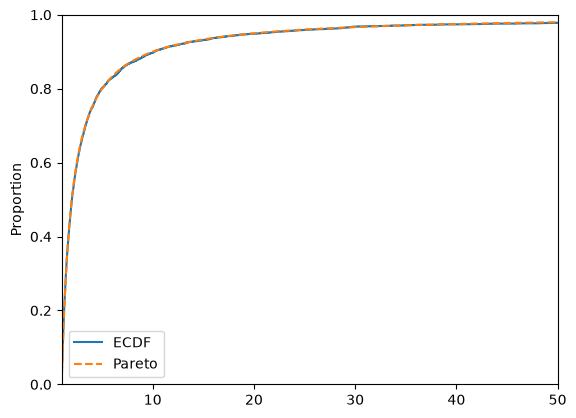

In [26]:
sns.ecdfplot(sizes, label='ECDF')

x = np.linspace(1, 50, 200)

plt.plot(x, stats.pareto.cdf(x, 1, scale=1), '--', label='Pareto')

plt.xlim(1, 50)
plt.legend()

The pareto cdf with x_m = 1 and b=1 matches exactly, so as K becomes large this gives the pareto distribution.

Increasing s makes the large cities even larger relative to the rest of them, which gives a heavier tail and a smaller b, and decreasing s keeps the size more close to 1. 